# Penugasan 3 — Perbandingan Deteksi Tepi Menggunakan Foto Pribadi

Program ini melakukan perbandingan deteksi tepi menggunakan lima operator:
**Sobel, Roberts, Prewitt, Kirsch, dan Canny**
pada gambar yang diambil dari handphone sendiri.

Pastikan file gambar (`.jpg` / `.png`) sudah tersedia di folder yang sama dengan file notebook ini.

---
### Langkah 1 — Import Library

Import semua library yang dibutuhkan sebelum menjalankan program.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import color, filters, feature, io
from skimage.filters.rank import gradient
from skimage.morphology import disk

---
### Langkah 2 — Load Gambar dari File

Ganti nilai variabel `FILE_GAMBAR` dengan nama file foto kamu (termasuk ekstensinya).
Contoh: `'foto_saya.jpg'` atau `'gambar.png'`

Program akan otomatis mengkonversi gambar berwarna ke grayscale untuk keperluan deteksi tepi.

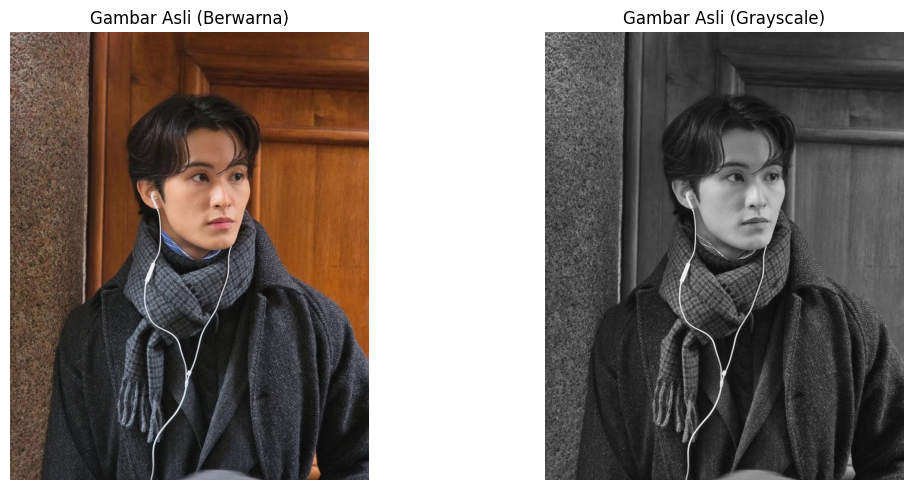

Gambar berhasil dimuat: mark.jpg
Ukuran gambar: (920, 736, 3)


In [2]:
FILE_GAMBAR = 'mark.jpg'

# Load gambar dari file
image_color = io.imread(FILE_GAMBAR)

# Konversi ke grayscale
if image_color.ndim == 3:
    image_gray = color.rgb2gray(image_color)
else:
    image_gray = image_color  # sudah grayscale

# Konversi grayscale ke uint8 untuk operator Kirsch
image_gray_uint8 = (image_gray * 255).astype(np.uint8)

# Tampilkan gambar asli
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image_color)
axes[0].set_title("Gambar Asli (Berwarna)")
axes[0].axis("off")

axes[1].imshow(image_gray, cmap='gray')
axes[1].set_title("Gambar Asli (Grayscale)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print(f"Gambar berhasil dimuat: {FILE_GAMBAR}")
print(f"Ukuran gambar: {image_color.shape}")

---
### Langkah 3 — Terapkan Semua Operator Deteksi Tepi

Kelima operator diterapkan pada citra grayscale hasil konversi dari foto pribadi.

In [3]:
# Sobel
sobel_edge = filters.sobel(image_gray)

# Roberts
roberts_edge = filters.roberts(image_gray)

# Prewitt
prewitt_edge = filters.prewitt(image_gray)

# Kirsch (menggunakan rank gradient dengan disk morphology)
kirsch_edge = gradient(image_gray_uint8, disk(1))

# Canny
canny_edge = feature.canny(image_gray, sigma=1)

print("Semua operator berhasil diterapkan.")

Semua operator berhasil diterapkan.


---
### Langkah 4 — Visualisasi Perbandingan Hasil Deteksi Tepi

Semua hasil ditampilkan dalam satu grid berdampingan untuk memudahkan perbandingan antar operator.

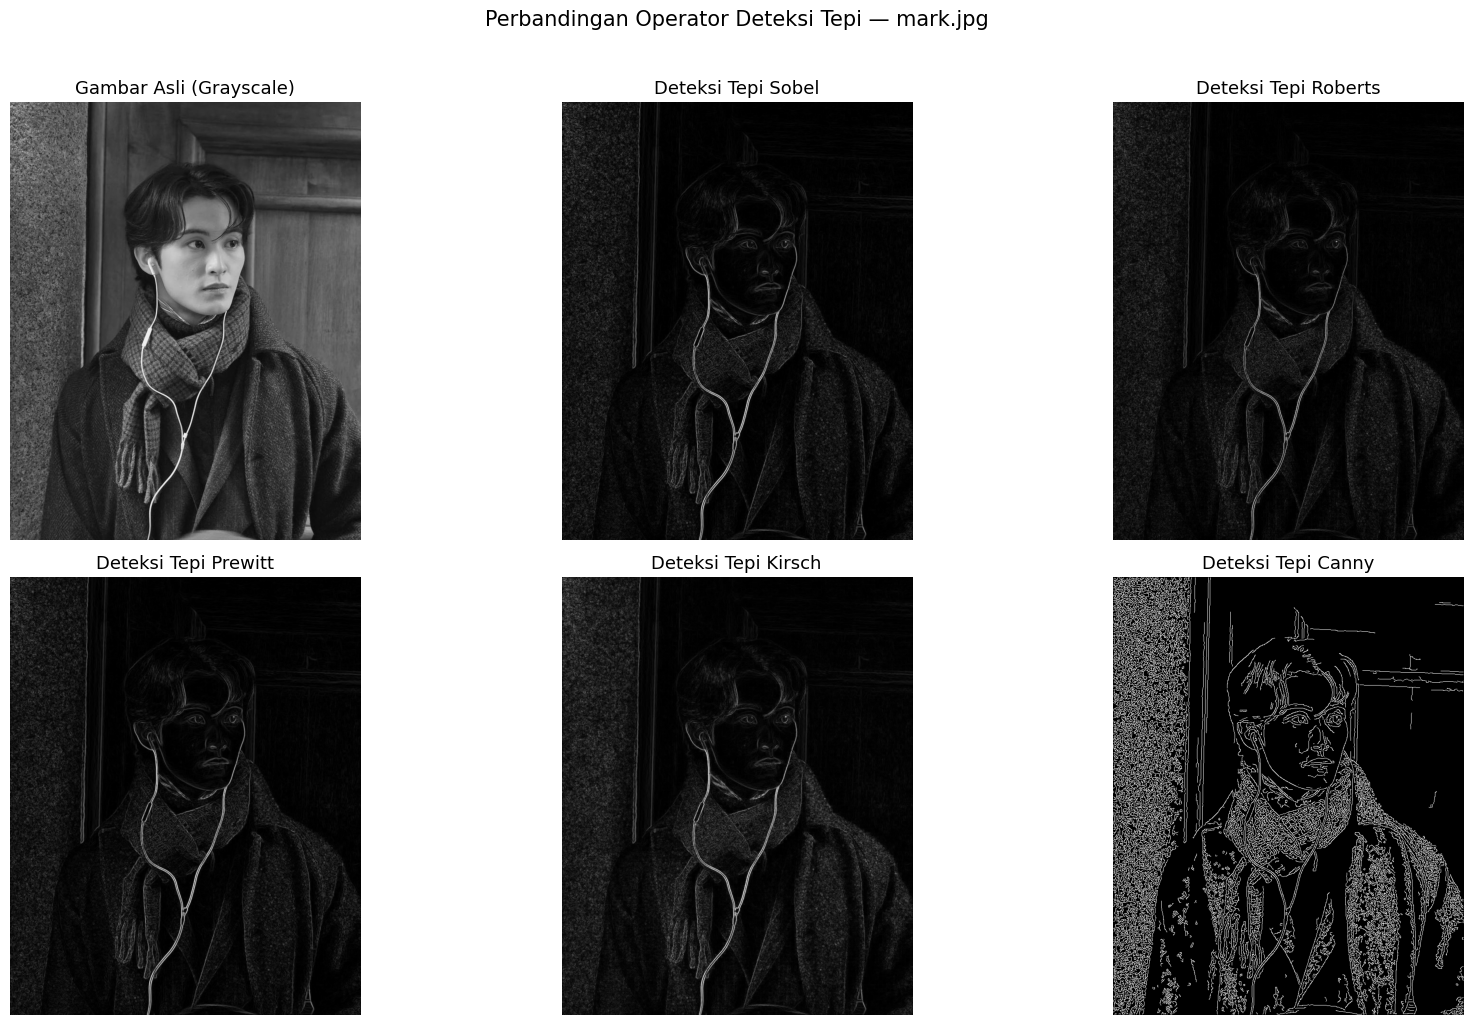

In [4]:
# Daftar hasil dan label
results = [
    (image_gray,   'Gambar Asli (Grayscale)', 'gray'),
    (sobel_edge,   'Deteksi Tepi Sobel',      'gray'),
    (roberts_edge, 'Deteksi Tepi Roberts',    'gray'),
    (prewitt_edge, 'Deteksi Tepi Prewitt',    'gray'),
    (kirsch_edge,  'Deteksi Tepi Kirsch',     'gray'),
    (canny_edge,   'Deteksi Tepi Canny',      'gray'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
ax = axes.ravel()

for i, (img, title, cmap) in enumerate(results):
    ax[i].imshow(img, cmap=cmap)
    ax[i].set_title(title, fontsize=13)
    ax[i].axis("off")

plt.suptitle(f"Perbandingan Operator Deteksi Tepi — {FILE_GAMBAR}", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

> Kesimpulan: Berdasarkan hasil deteksi tepi pada foto pribadi menggunakan lima operator, terlihat perbedaan karakteristik yang cukup jelas. Operator Sobel dan Prewitt menghasilkan tepi yang serupa — keduanya mampu mendeteksi kontur wajah, syal, dan earphone dengan ketebalan sedang, namun Sobel sedikit lebih tajam pada area dengan perubahan intensitas tinggi seperti tepi rambut. Operator Roberts menghasilkan tepi yang lebih tipis dan samar, terutama pada area gelap gambar, menunjukkan kelemahannya pada citra dengan kontras rendah. Operator Kirsch menghasilkan tepi yang mirip dengan Sobel dan Prewitt namun sedikit lebih tebal, terutama terlihat pada area syal dan jaket. Operator Canny memberikan hasil yang paling berbeda dan paling informatif — tepi yang dihasilkan sangat tipis namun lengkap, mampu mendeteksi detail halus seperti tekstur rambut, lipatan pakaian, dan kabel earphone dengan lebih jelas dibanding operator lainnya, meskipun pada area background yang gelap Canny juga mendeteksi lebih banyak noise. Secara keseluruhan, untuk citra seperti foto ini yang memiliki area gelap dominan, Canny adalah operator terbaik karena menghasilkan tepi paling detail dan bersih, sementara Roberts kurang cocok karena menghasilkan tepi yang terlalu tipis dan kurang terlihat.